In [3]:
import scanpy as sc
import os
import pandas as pd
import matplotlib as mpl
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('/Users/amossi/Documents/code/')
import FISHspace as sp

%reload_ext autoreload
%autoreload 2

mpl.rcParams['pdf.fonttype'] = 42

# save figure with no pad
mpl.rcParams['savefig.pad_inches'] = 0
mpl.rcParams['savefig.bbox'] = 'tight'

# set axes width
mpl.rcParams['axes.linewidth'] = 0.2
mpl.rcParams['xtick.minor.pad'] = 0
mpl.rcParams['xtick.major.pad'] = 0
mpl.rcParams['ytick.minor.pad'] = 0
mpl.rcParams['ytick.major.pad'] = 0
mpl.rcParams['xtick.minor.width'] = 0.2
mpl.rcParams['xtick.major.width'] = 0.2
mpl.rcParams['ytick.minor.width'] = 0.2
mpl.rcParams['ytick.major.width'] = 0.2

# Full Data

In [ ]:
gbo_path = '../../data_for_visualization/GBMOrganoids_scVIsurgery20240408.h5ad'
adata_full = sc.read_h5ad(gbo_path)

In [8]:
annotation_colors = {
    '+HYP2':'#840034',
    'preOPC': '#7befb2',
    'RG':'#ff9470',
    '+HYP1':'#C50F53',
    'AC1':'#2ecc71',
    'nIPC':'#FFF192',
    'OPC':'#89c4f4',
    'GBL':'#b9e670',
    'hAC':'#EDE8F3',
    'AC2':'#2ecc71',
    'FBL':'#9f5afd',
    'rAC':'#e3ba8f',
    'cOPC':'#038aff',
    'Unknown':'#efeff0',
}

<Figure size 500x500 with 0 Axes>

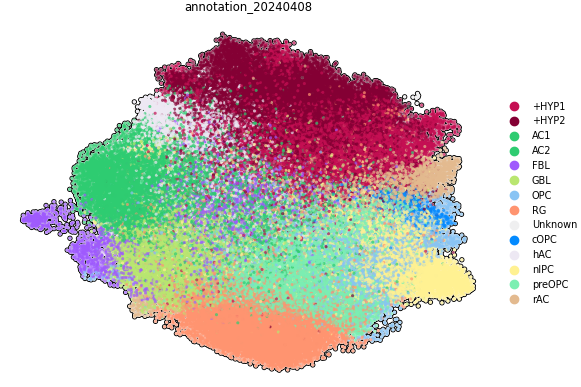

In [11]:
plt.figure(figsize=(5,5))
sc.pl.umap(
    adata_full,
    color=["annotation_20240408"],
    frameon=False,
    add_outline=True,
    ncols=4,
    s=20,
    show=False,
)
plt.savefig('figures/GBO_scVI.png',transparent=True,format='png', dpi=300)
plt.show()

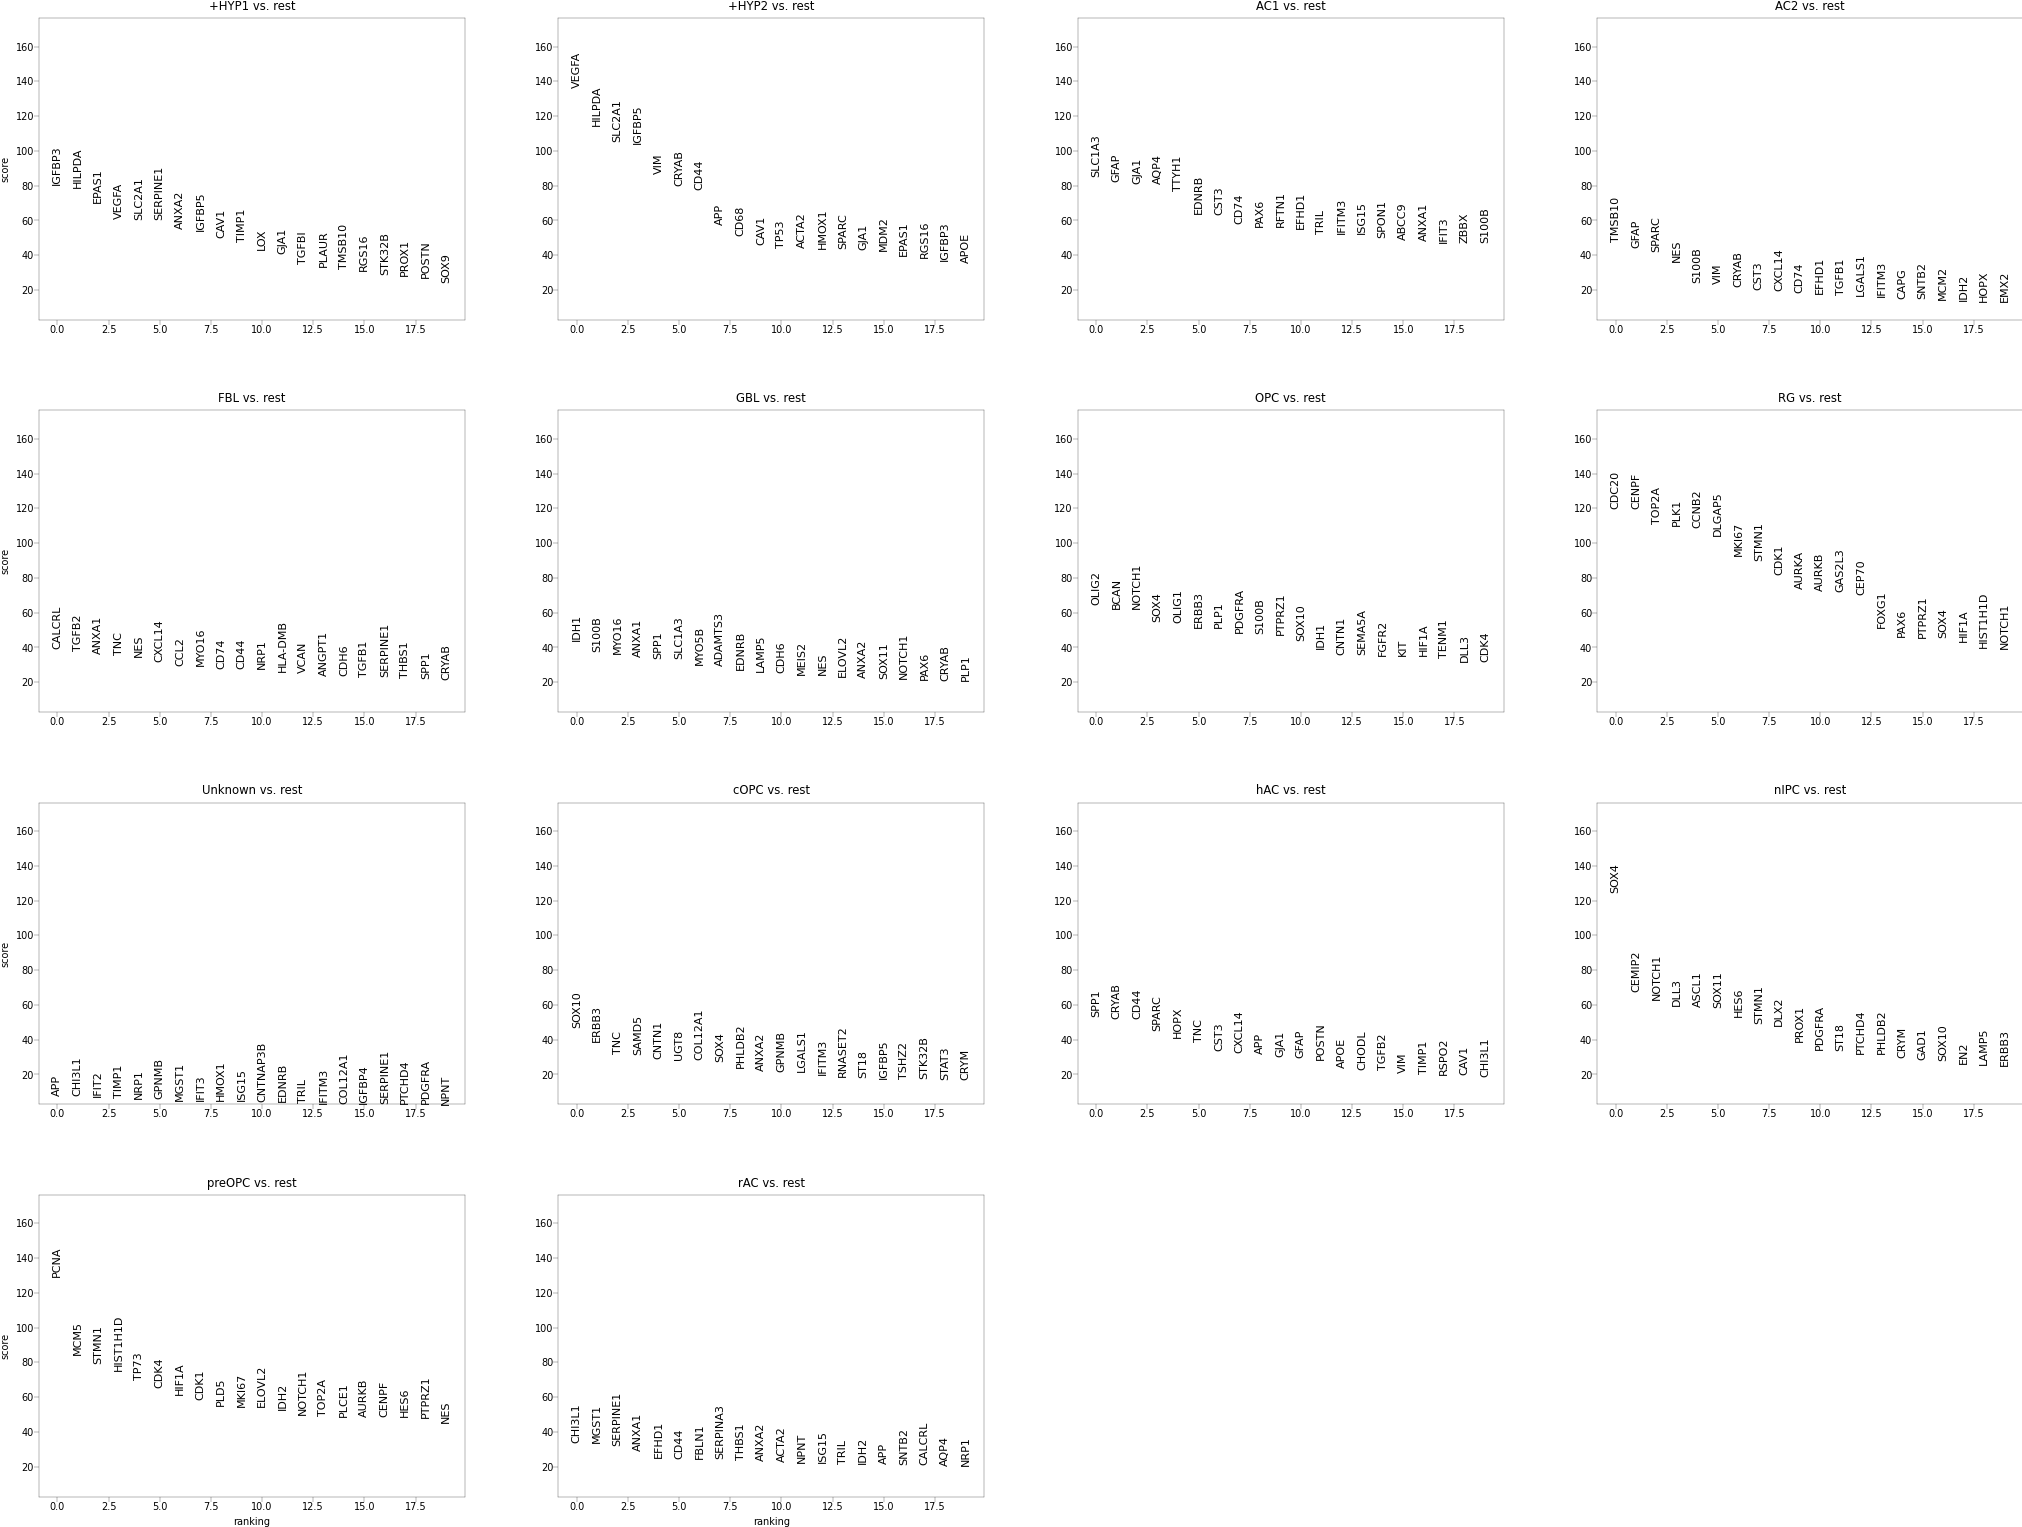

In [12]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sc.tl.rank_genes_groups(adata_full, groupby="annotation_20240408", method='t-test')
sc.pl.rank_genes_groups(adata_full)

# Heatmap

In [13]:
adata = adata_full[adata_full.obs['annotation_20240408'] != 'Unknown'].copy()
adata.X = adata.raw.X
adata.X.toarray()

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 8., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 6., 0., ..., 0., 0., 0.]], shape=(164263, 366), dtype=float32)

In [14]:
adata.X = adata.X.toarray()

In [15]:
sp.pp.preprocess(
    adata,
    batch_key='line',
    batch_correction=False,
    scaling=True,
    keep_raw=False,
    max_quant=.95
)

In [19]:
marker_genes_dict = {
    'GBL':['TTYH1', 'EDNRB', 'BCAN', 'TNC'],
    'OPC':['PDGFRA', 'SOX10','OLIG1', 'OLIG2'],
    'nIPC':['ASCL1','ST18'],
    'RG':['HES1', 'PAX6', 'PCNA'],
    'preOPC':['EGFR', 'DLL3'],
    
    'AC1': ['AQP4','GJA1'],
    'AC2':['GFAP','NES'],
    
    'FBL':['COL3A1','COL1A1'],
    'rAC': ['SERPINE1', 'SERPINA3','CHI3L1','APOE', 'MGST1'],
    'cOPC':['UGT8','PLP1','MOG'],
    'hAC':['SPP1','CST3'],
    '+HYP1': ['CD44', 'ANXA1', 'EPAS1', 'ANXA2'],
    '+HYP2':['CRYAB','MDM2','VEGFA','HILPDA'],


    
}

In [20]:
#import itertools
#markers = list(itertools.chain.from_iterable(marker_genes_dict.values()))

In [21]:
sc.tl.dendrogram(adata, groupby="annotation_20240408")

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'MATH': 51 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'X', 'Y', 'a', 'c', 'e', 'eight', 'five', 'four', 'g', 'h', 'i', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'plus', 'r', 's', 'seven', 'six', 'space', 'three', 'two', 'u', 'x', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 14, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 59, 60, 68, 70, 72, 74, 7

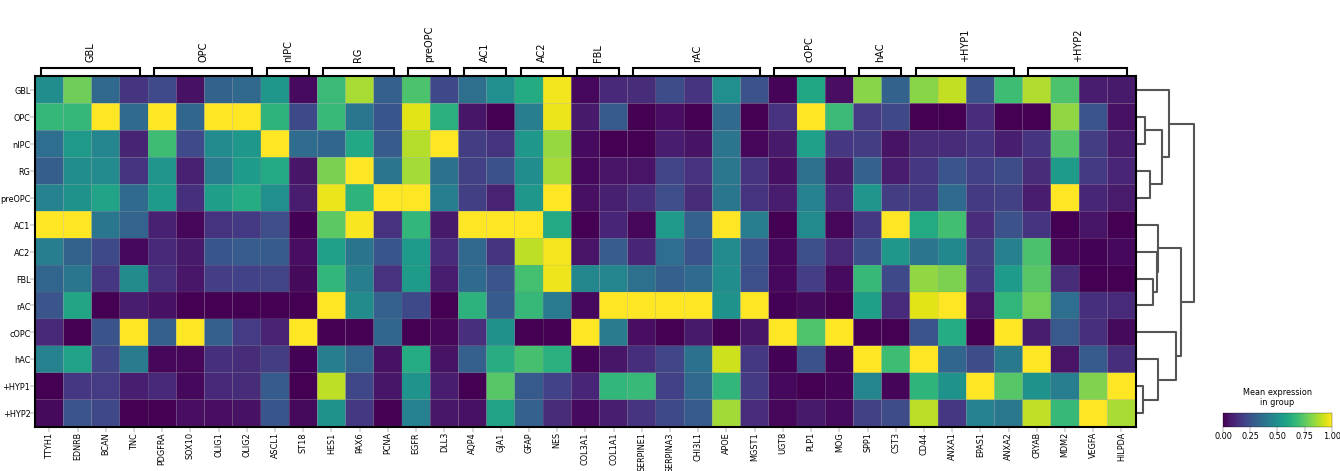

In [23]:
sc.pl.matrixplot(
    adata,#[adata_full.obs.line == 'SL013'],
    marker_genes_dict,
    "annotation_20240408",
    dendrogram=True,
    standard_scale='var',
    #colorbar_title="mean z-score",
    log=True,
    use_raw=False,
    #layer="counts",
    #vmin=-2,
    #vmax=.9999,
    #save='../ExtendedFigure6/figures/Heatmap_GBO.pdf',
    show=False,
    cmap="viridis",
)
plt.savefig('figures/Heatmap_GBO.pdf',dpi=300, transparent=True,)
plt.show()
